# 🌳 Yggdrasil — Árvore de segmentação **unificada** (classificação & regressão)

Tutorial do subpacote `yggdrasil.credit_risk.tree`. Uma **única classe**
(`TreeSegmenter`) e uma **única UI** (`TreeSegmenterUI`) atendem os dois problemas
de risco de crédito, escolhendo o comportamento por `task_type`:

| `task_type` | alvo | binning | IV | métricas | gráficos |
|---|---|---|---|---|---|
| `"classification"` | binário 0/1 | `OptimalBinning` | WoE (Siddiqi) | KS/AUC/Gini/Acurácia/F1 | ROC, KS, taxa-default, score |
| `"regression"` | contínuo [0,1] | `ContinuousOptimalBinning` | IV contínuo | MAE/RMSE/R² | boxplot, histograma do alvo |

> Substitui as antigas classes separadas `SequentialPDSegmenter`/`SequentialLGDSegmenter`.
> A régua, a poda, o PSI/CSI, o backtest, a calibração, o `predict`/`to_pyspark`/
> `apply_spark`/`to_sql` e o `log_to_mlflow` são **os mesmos** nos dois modos.

**Instalação** (na raiz do repositório):
```bash
pip install -e ".[ui]"          # núcleo + interface interativa
pip install -e ".[ui,optuna]"   # + tuning bayesiano do ModelSegmenter
```
> No Databricks: `%pip install -e ".[ui]"` num cluster interativo DBR 13.0+.
> ⚠️ O `optbinning` 0.20 exige `scikit-learn<1.8` (já fixado no `pyproject`).

In [1]:
# --- Bootstrap: torna o pacote `yggdrasil` importável a partir do repositório,
# sem `pip install`. Procura a raiz do repo (a pasta que contém `yggdrasil/`) por
# vários âncoras — o caminho do próprio notebook (VS Code expõe `__vsc_ipynb_file__`),
# o diretório atual, os diretórios do sys.path e, no Databricks, o caminho via
# dbutils — subindo até achá-la, e a insere no sys.path. Cobre Jupyter/VS Code
# local e Databricks; se o pacote já estiver importável, é inócuo.
import sys
from pathlib import Path

def _find_yggdrasil_root():
    _anchors = []
    for _n in ("__vsc_ipynb_file__", "__file__", "__session__"):
        _v = globals().get(_n)
        if _v:
            _anchors.append(Path(str(_v)))
    _anchors.append(Path.cwd())
    _anchors += [Path(_p) for _p in sys.path if _p not in ("", ".")]
    for _a in _anchors:
        try:
            _a = _a.resolve()
        except Exception:
            continue
        for _b in (_a, *_a.parents):
            if (_b / "yggdrasil" / "__init__.py").is_file():
                return _b
    try:  # fallback Databricks: caminho do próprio notebook
        _nbp = (dbutils.notebook.entry_point.getDbutils()  # noqa: F821
                .notebook().getContext().notebookPath().get())
        for _pref in ("/Workspace", ""):
            for _b in Path(_pref + _nbp).parents:
                if (_b / "yggdrasil" / "__init__.py").is_file():
                    return _b
    except Exception:
        pass
    return None

_ygg_root = _find_yggdrasil_root()
if _ygg_root and str(_ygg_root) not in sys.path:
    sys.path.insert(0, str(_ygg_root))


In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
from IPython.display import display
from yggdrasil.credit_risk.tree import TreeSegmenter

# --- base sintética de crédito: MESMAS features p/ os dois alvos -------------
# Features: comprometimento de renda, score de bureau (com faltantes), meses de
# relacionamento e tipo de garantia. dt_ref = safra (fora da modelagem).
# Amostras: DES (referência), OOT (out-of-time) e ESTABILIDADE (recente).
rng = np.random.default_rng(42)
GAR = {'alienacao': -0.55, 'aval': 0.15, 'fianca': 0.45, 'sem garantia': 1.05}

def gera(n, t0='2022-01-01'):
    dt_ref = pd.to_datetime(t0) + pd.to_timedelta(rng.integers(0, 365, n), unit='D')
    midx = (dt_ref.year.values - 2022) * 12 + (dt_ref.month.values - 1)
    comp = rng.beta(2.5, 3, n) * 0.8 + 0.1 + 0.004 * midx        # comprometimento migra no tempo
    score = np.clip(rng.normal(640, 95, n), 300, 900)
    score[rng.random(n) < 0.06] = np.nan                          # ~6% de score faltante
    relac = rng.integers(0, 120, n)
    gar = rng.choice(list(GAR), n, p=[0.50, 0.22, 0.18, 0.10]).astype(object)
    risco = (2.6 * (comp - 0.4) - 0.0045 * (np.nan_to_num(score, nan=640) - 640)
             - 0.004 * relac + np.array([GAR[g] for g in gar]))
    # alvo de CLASSIFICAÇÃO (default 0/1)
    p = 1 / (1 + np.exp(-(-2.15 + risco)))
    default = (rng.uniform(0, 1, n) < p).astype(float)
    # alvo de REGRESSÃO (severidade em [0,1])
    severidade = np.clip(0.45 + 0.18 * risco + rng.normal(0, 0.12, n), 0, 1)
    return pd.DataFrame({'comprometimento_renda': comp, 'score_bureau': score,
                         'meses_relacionamento': relac, 'tipo_garantia': gar,
                         'dt_ref': dt_ref, 'default': default, 'severidade': severidade})

des = gera(6000, '2022-01-01'); des['amostra'] = 'DES'
oot = gera(2500, '2023-07-01'); oot['amostra'] = 'OOT'
est = gera(1800, '2024-01-01'); est['amostra'] = 'ESTABILIDADE'
est['default'] = np.nan; est['severidade'] = np.nan          # público recente: ainda sem alvo
base = pd.concat([des, oot, est], ignore_index=True)

FEATS = ['comprometimento_renda', 'score_bureau', 'meses_relacionamento', 'tipo_garantia']
LABELS = {'comprometimento_renda': 'comprometimento de renda', 'score_bureau': 'score de bureau',
          'meses_relacionamento': 'meses de relacionamento', 'tipo_garantia': 'garantia'}
# views por tarefa (só o alvo relevante vira 'target'; o outro alvo fica de fora)
df_clf = base[FEATS + ['dt_ref', 'amostra', 'default']].rename(columns={'default': 'target'})
df_reg = base[FEATS + ['dt_ref', 'amostra', 'severidade']].rename(columns={'severidade': 'target'})
base.groupby('amostra', sort=False).agg(n=('default', 'size'),
                                        taxa_default=('default', 'mean'),
                                        severidade_media=('severidade', 'mean')).round(4)

,n,taxa_default,severidade_media
amostra,,,
DES,6000,0.1182,0.4341
OOT,2500,0.1396,0.4701
ESTABILIDADE,1800,NaN,NaN


## 1) Classificação — `task_type="classification"`
A mesma API de sempre. O `fit_auto` cresce a árvore gulosa por **IV (WoE binário)**.

In [3]:
seg_clf = TreeSegmenter(df_clf, target='target', task_type='classification',
                       sample_col='amostra', ref_sample='DES', date_col='dt_ref',
                       feature_labels=LABELS)
seg_clf.fit_auto(max_depth=3, min_iv=0.02)
display(seg_clf.leaves(with_psi=True).head(8))
display(seg_clf.metrics())                 # KS / AUC / Gini / Acurácia / F1 por amostra

[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


[fit_auto] árvore gulosa construída: profundidade 3 (máx +3), IV mínimo 0.02 → 12 folhas


,segmento,nota,descricao,profundidade,n,repr_%,valor_medio,valor_std,valor_DES,valor_OOT,valor_ESTABILIDADE,repr_DES_%,psi_OOT,repr_OOT_%,psi_ESTABILIDADE,repr_ESTABILIDADE_%
0,tipo_garantia: {alienacao} | comprometimento_r...,1,garantia em {alienacao} e comprometimento de r...,3,1774,17.2,0.0357,0.1908,0.0357,0.0455,NaN,20.5,0.0323,13.2,0.0478,11.8
1,tipo_garantia: {alienacao} | comprometimento_r...,2,garantia em {alienacao} e comprometimento de r...,3,126,1.2,0.0482,0.2066,0.0482,0.0333,NaN,1.4,0.0003,1.2,0.0043,0.7
2,tipo_garantia: {alienacao} | comprometimento_r...,3,garantia em {alienacao} e comprometimento de r...,3,491,4.8,0.0779,0.2726,0.0779,0.0885,NaN,5.3,0.0014,4.5,0.0114,3.2
3,tipo_garantia: {alienacao} | comprometimento_r...,4,garantia em {alienacao} e (comprometimento de ...,3,183,1.8,0.0549,0.2837,0.0549,0.1522,NaN,1.5,0.0006,1.8,0.0054,2.6
4,tipo_garantia: {alienacao} | comprometimento_r...,5,garantia em {alienacao} e (comprometimento de ...,3,1230,11.9,0.0665,0.2599,0.0665,0.0840,NaN,10.5,0.0114,14.3,0.0068,13.4
5,tipo_garantia: {alienacao} | comprometimento_r...,6,garantia em {alienacao} e (comprometimento de ...,3,1314,12.8,0.1450,0.3484,0.1450,0.1342,NaN,11.0,0.0100,14.6,0.0181,15.9
6,"tipo_garantia: {aval, fianca, sem garantia} | ...",7,(garantia em {aval ou fianca ou sem garantia} ...,3,426,4.1,0.0359,0.1969,0.0359,0.0635,NaN,5.6,0.0241,2.5,0.0490,1.6
7,"tipo_garantia: {aval, fianca, sem garantia} | ...",8,(garantia em {aval ou fianca ou sem garantia} ...,3,1670,16.2,0.1281,0.3504,0.1281,0.1748,NaN,15.0,0.0030,17.2,0.0099,19.1


,amostra,n,taxa_default,KS,AUC,Gini,Acuracia,F1
0,DES,6000,0.1182,0.301062,0.701323,0.402646,0.539833,0.290049
1,OOT,2500,0.1396,0.213416,0.639184,0.278367,0.461600,0.295288
2,ESTABILIDADE,1800,NaN,NaN,NaN,NaN,NaN,NaN


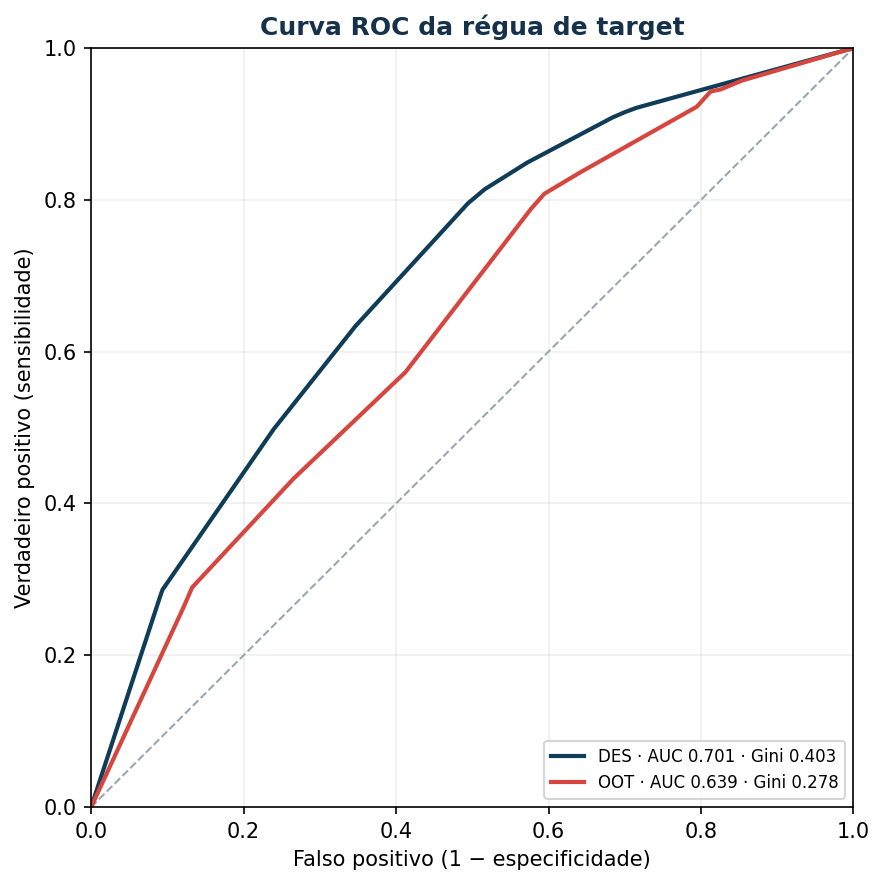

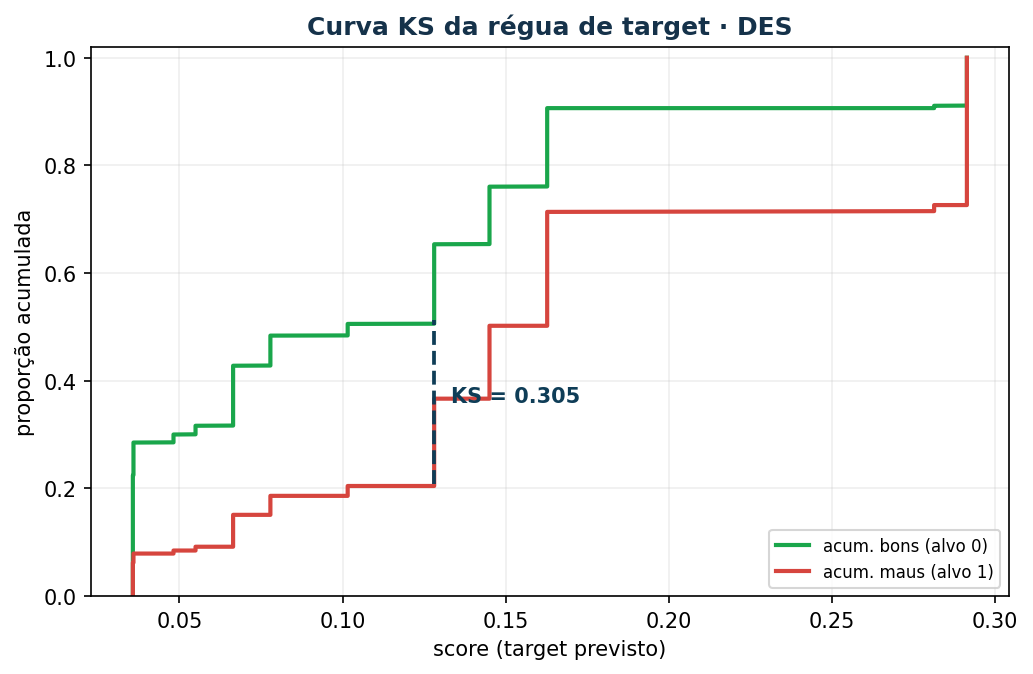

,variavel,tipo,n_bins,iv,forca,pior_psi,psi_classificacao
0,tipo_garantia,cat,4,0.2772,médio,0.0077,estável
1,comprometimento_renda,num,5,0.2133,médio,0.4410,instável
2,score_bureau,num,6,0.1962,médio,0.0027,estável
3,meses_relacionamento,num,5,0.0517,fraco,0.0034,estável


In [4]:
# discriminação visual + ranking de variáveis por IV
display(seg_clf.plot_roc())
display(seg_clf.plot_ks())
seg_clf.variable_iv('root')[['variavel', 'tipo', 'n_bins', 'iv', 'forca', 'pior_psi', 'psi_classificacao']]

## 2) Regressão — `task_type="regression"`
**Mesma chamada, só muda o `task_type` e o alvo.** Agora o IV é contínuo e as
métricas são MAE/RMSE/R². Os gráficos específicos são boxplot e histograma do alvo.

[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


[fit_auto] árvore gulosa construída: profundidade 3 (máx +3), IV mínimo 0.01 → 11 folhas


,segmento,nota,descricao,profundidade,n,repr_%,valor_medio,valor_std,valor_DES,valor_OOT,valor_ESTABILIDADE,repr_DES_%,psi_OOT,repr_OOT_%,psi_ESTABILIDADE,repr_ESTABILIDADE_%
0,"tipo_garantia: {alienacao, aval, fianca} | tip...",1,garantia em {alienacao ou aval ou fianca} e ga...,3,4387,42.6,0.3340,0.1549,0.3340,0.3709,NaN,43.5,0.0006,41.8,0.0020,40.6
1,"tipo_garantia: {alienacao, aval, fianca} | tip...",2,garantia em {alienacao ou aval ou fianca} e ga...,3,309,3.0,0.3509,0.1440,0.3509,0.4137,NaN,2.9,0.0001,3.0,0.0005,3.3
2,"tipo_garantia: {alienacao, aval, fianca} | tip...",3,garantia em {alienacao ou aval ou fianca} e ga...,3,422,4.1,0.5012,0.1400,0.5012,0.5191,NaN,3.9,0.0016,4.8,0.0001,3.7
3,"tipo_garantia: {alienacao, aval, fianca} | tip...",4,garantia em {alienacao ou aval ou fianca} e (g...,3,2290,22.2,0.4737,0.1626,0.4737,0.5044,NaN,22.2,0.0004,23.2,0.0006,21.1
4,"tipo_garantia: {alienacao, aval, fianca} | tip...",5,garantia em {alienacao ou aval ou fianca} e (g...,3,1848,17.9,0.5208,0.1547,0.5208,0.5455,NaN,17.6,0.0000,17.5,0.0018,19.5
5,tipo_garantia: {sem garantia} | score_bureau: ...,6,(garantia em {sem garantia} ou faltante) e sco...,3,14,0.1,0.3353,0.1263,0.3353,0.2993,NaN,0.1,0.0007,0.2,0.0003,0.2
6,tipo_garantia: {sem garantia} | score_bureau: ...,7,(garantia em {sem garantia} ou faltante) e sco...,3,37,0.4,0.4994,0.1123,0.4994,0.5332,NaN,0.4,0.0002,0.3,0.0004,0.3
7,tipo_garantia: {sem garantia} | score_bureau: ...,8,(garantia em {sem garantia} ou faltante) e sco...,3,3,0.0,0.3864,0.2165,0.3864,NaN,NaN,0.1,0.0031,0.0,0.0031,0.0


,amostra,n,MAE,RMSE,R2
0,DES,6000,0.1243,0.1549,0.3045
1,OOT,2500,0.1246,0.1566,0.2678
2,ESTABILIDADE,1800,NaN,NaN,NaN


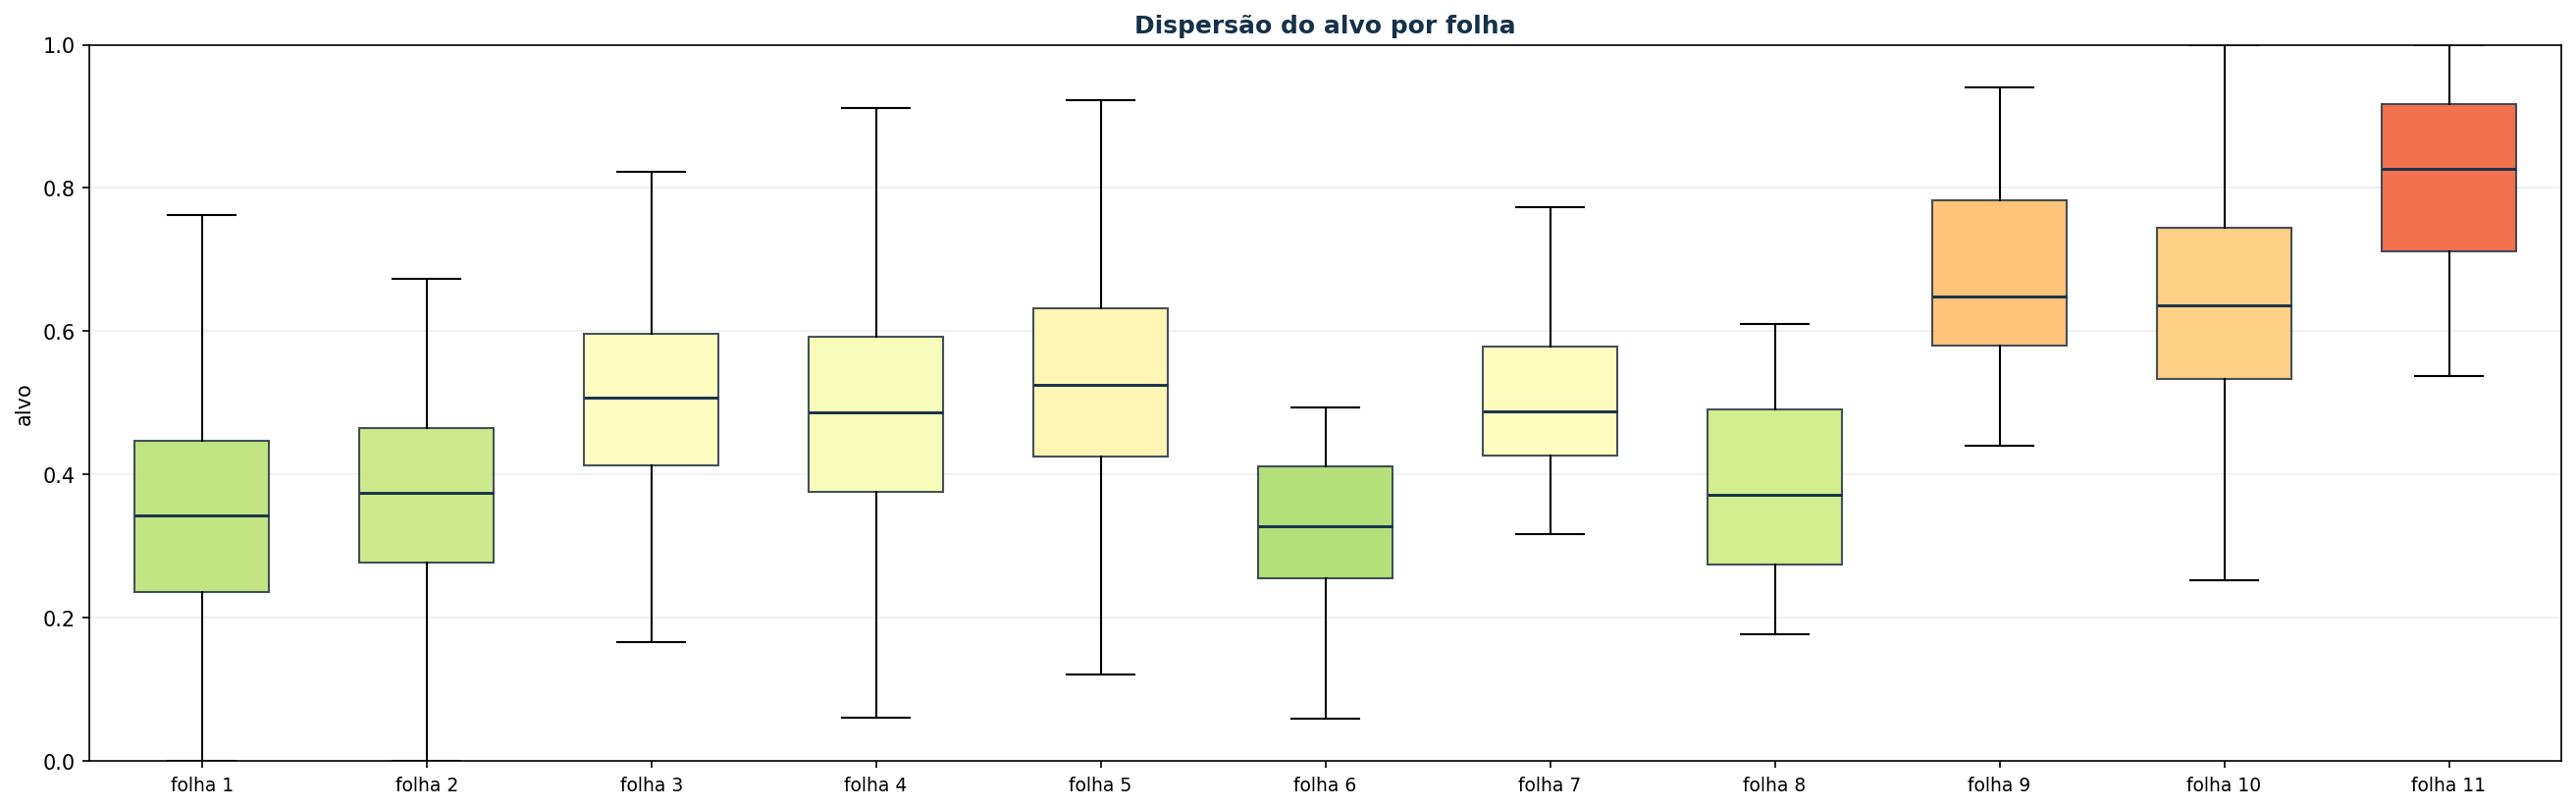

In [5]:
seg_reg = TreeSegmenter(df_reg, target='target', task_type='regression',
                        sample_col='amostra', ref_sample='DES', date_col='dt_ref',
                        feature_labels=LABELS)
seg_reg.fit_auto(max_depth=3, min_iv=0.01)
display(seg_reg.leaves(with_psi=True).head(8))
display(seg_reg.metrics())                # MAE / RMSE / R² por amostra
display(seg_reg.plot_leaf_boxplots())     # dispersão do alvo por folha

## 3) Critério de split selecionável
Além do binning ótimo (`optbin`, multi-bin por IV), o `fit_auto`/`grow` aceitam um
**critério de split binário** (CART/CHAID) via `criterion=`:

- **classificação:** `gini`, `entropy`, `ks`, `iv`, `chi2`
- **regressão:** `variance`, `mae`, `ftest`

In [6]:
for crit in ['optbin', 'ks', 'gini', 'chi2']:
    s = TreeSegmenter(df_clf, target='target', task_type='classification',
                      sample_col='amostra', ref_sample='DES', feature_labels=LABELS)
    s.fit_auto(max_depth=3, criterion=crit, verbose=False)
    nf = sum(v['is_leaf'] for v in s.segments.values())
    auc = s.metrics().query("amostra=='DES'")['AUC'].iloc[0]
    print(f"clf · criterion={crit:7} → {nf:2d} folhas · AUC(DES)={auc:.3f}")

for crit in ['optbin', 'variance', 'mae']:
    s = TreeSegmenter(df_reg, target='target', task_type='regression',
                      sample_col='amostra', ref_sample='DES', feature_labels=LABELS)
    s.fit_auto(max_depth=3, criterion=crit, verbose=False)
    nf = sum(v['is_leaf'] for v in s.segments.values())
    r2 = s.metrics().query("amostra=='DES'")['R2'].iloc[0]
    print(f"reg · criterion={crit:8} → {nf:2d} folhas · R²(DES)={r2:.3f}")

[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


clf · criterion=optbin  → 12 folhas · AUC(DES)=0.701
[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


clf · criterion=ks      → 12 folhas · AUC(DES)=0.698
[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


clf · criterion=gini    → 12 folhas · AUC(DES)=0.688
[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


clf · criterion=chi2    → 11 folhas · AUC(DES)=0.685
[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


reg · criterion=optbin   →  6 folhas · R²(DES)=0.294
[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


reg · criterion=variance → 12 folhas · R²(DES)=0.426
[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


reg · criterion=mae      → 12 folhas · R²(DES)=0.427


## 4) Sugerir splits (TOP 3) e importância das variáveis
`suggest_splits(sid, top)` ranqueia as melhores variáveis para dividir uma folha,
com **nº de bins, IV, PSI por amostra (OOT/ESTABILIDADE), se passa no teste de
hipótese e o p-valor**. `feature_importance()` resume o ganho das variáveis que
**entraram** na árvore.

In [7]:
print('clf — TOP 3 splits para a raiz:')
display(seg_clf.suggest_splits('root', top=3))
print('clf — importância das variáveis na árvore:')
display(seg_clf.feature_importance())
print('reg — importância das variáveis na árvore:')
display(seg_reg.feature_importance())

clf — TOP 3 splits para a raiz:


,variavel,n_bins,iv,forca,psi_OOT,psi_ESTABILIDADE,psi_classificacao,passa_teste,p_valor
0,tipo_garantia,4,0.2772,médio,0.0005,0.0077,estável,True,0.0
1,comprometimento_renda,5,0.2133,médio,0.2583,0.4410,instável,True,0.0
2,score_bureau,6,0.1962,médio,0.0026,0.0027,estável,True,0.0


clf — importância das variáveis na árvore:


,variavel,n_splits,importancia,importancia_%
0,comprometimento de renda,4,0.278457,35.65
1,garantia,1,0.277200,35.48
2,score de bureau,3,0.225525,28.87


reg — importância das variáveis na árvore:


,variavel,n_splits,importancia,importancia_%
0,garantia,3,0.160892,81.73
1,score de bureau,3,0.031932,16.22
2,comprometimento de renda,2,0.004038,2.05


## 5) Auto-merge de folhas semelhantes
`auto_merge` funde folhas-irmãs com risco **estatisticamente indistinguível**
(p > α no teste entre adjacentes) — simplifica a régua sem perder separação.

In [8]:
antes = sum(v['is_leaf'] for v in seg_clf.segments.values())
seg_clf.auto_merge(alpha=0.05)
depois = sum(v['is_leaf'] for v in seg_clf.segments.values())
print(f'clf: folhas {antes} → {depois} após auto-merge')

[auto_merge] 0 fusão(ões) automática(s) (alpha=0.05, min_valor_gap=0.0, include_missing=False). Folhas finais: 12
clf: folhas 12 → 12 após auto-merge


## 6) Exportar a régua: `predict`, **SQL (CASE WHEN)** e PySpark
A régua é aplicável em pandas (`predict`), gera **SQL copiável** (`to_sql`) e código
PySpark (`to_pyspark`). Faltantes são roteados para o bin `(faltante)` — nada é descartado.

In [9]:
novos = gera(800).drop(columns=['default', 'severidade'])
display(seg_clf.predict(novos).head())             # segmento · nota · valor_regua
print(seg_clf.to_sql(table='carteira_credito'))    # cole no seu SQL

,segmento,nota,valor_regua
0,tipo_garantia: {alienacao} | comprometimento_r...,6,0.145015
1,tipo_garantia: {alienacao} | comprometimento_r...,1,0.035743
2,tipo_garantia: {alienacao} | comprometimento_r...,1,0.035743
3,"tipo_garantia: {aval, fianca, sem garantia} | ...",12,0.291291
4,tipo_garantia: {alienacao} | comprometimento_r...,1,0.035743


-- Régua de segmentação (classification) gerada por TreeSegmenter
SELECT
  *,
  CASE
    WHEN (CAST(tipo_garantia AS STRING) IN ('alienacao')) AND (comprometimento_renda <= 0.5006638765335083) AND (score_bureau > 564.4178771972656) THEN 'tipo_garantia: {alienacao} | comprometimento_renda: (-inf, 0.5007] | score_bureau: (564.4, inf]'
    WHEN (CAST(tipo_garantia AS STRING) IN ('alienacao')) AND (comprometimento_renda <= 0.5006638765335083) AND score_bureau IS NULL THEN 'tipo_garantia: {alienacao} | comprometimento_renda: (-inf, 0.5007] | score_bureau: (faltante)'
    WHEN (CAST(tipo_garantia AS STRING) IN ('alienacao')) AND (comprometimento_renda <= 0.5006638765335083) AND (score_bureau <= 564.4178771972656) THEN 'tipo_garantia: {alienacao} | comprometimento_renda: (-inf, 0.5007] | score_bureau: (-inf, 564.4]'
    WHEN (CAST(tipo_garantia AS STRING) IN ('alienacao')) AND ((comprometimento_renda > 0.5006638765335083) OR comprometimento_renda IS NULL) AND score_bureau IS NULL THEN 'tipo_g

## 7) Comparar duas versões da árvore (`diff_trees`)
Compara a régua de duas árvores sobre a mesma base: **migração de notas**
(para onde as linhas vão), **concordância** e **métricas lado a lado**.

In [10]:
seg_clf_v2 = TreeSegmenter(df_clf, target='target', task_type='classification',
                          sample_col='amostra', ref_sample='DES', feature_labels=LABELS)
seg_clf_v2.fit_auto(max_depth=2, verbose=False)     # versão mais rasa
d = seg_clf.diff_trees(seg_clf_v2)
print(f"concordância de notas: {d['concordancia']:.1%}")
display(d['resumo'])
display(d['migracao'])

[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES


concordância de notas: 17.2%


,métrica,árvore A,árvore B,Δ (B−A)
0,nº de folhas,12.0000,5.0000,-7.0000
1,AUC · DES,0.7013,0.6636,-0.0377
2,AUC · OOT,0.6392,0.6028,-0.0364
3,AUC · ESTABILIDADE,NaN,NaN,NaN


nota_B,1,2,3,4,5
nota_A,,,,,
1,1774,0,0,0,0
2,126,0,0,0,0
3,491,0,0,0,0
4,0,183,0,0,0
5,0,1230,0,0,0
6,0,1314,0,0,0
7,0,0,426,0,0
8,0,0,1670,0,0
9,0,0,0,191,0


## 8) Registrar no MLflow / Unity Catalog
`log_to_mlflow` registra a régua como modelo `pyfunc` e loga, **conforme o
`task_type`**:

- **params:** `variaveis` (que entraram na árvore), `profundidade`, `n_folhas`,
  `target`, `ref_sample`, ...
- **métricas:** `profundidade`, `n_variaveis`, **PSI por amostra** (`psi_OOT`,
  `psi_ESTABILIDADE`, ...) e as **métricas do modelo** — classificação:
  `ks_*`/`auc_*`/`gini_*`/`acuracia_*`/`f1_*`; regressão: `mae_*`/`rmse_*`/`r2_*`.
- **artefatos:** `folhas.csv`, `arvore.txt`, `regua.sql`, `regua_pyspark.py`,
  `regua.json`, `arvore.json` (para recarregar via `TreeSegmenter.load`).

```python
# classificação
seg_clf.log_to_mlflow(experiment='/Users/voce/clf_seg',
                     registered_model_name='catalogo.schema.clf_segmentacao',
                     registry_uri='databricks-uc')
# regressão — mesma chamada
seg_reg.log_to_mlflow(experiment='/Users/voce/reg_seg',
                      registered_model_name='catalogo.schema.reg_segmentacao',
                      registry_uri='databricks-uc')
```

## 9) Interface interativa unificada — `TreeSegmenterUI`
A mesma UI atende os dois modos trocando só o `task_type`. 6 abas: **Construir**,
**Análise de variáveis**, **Diagnóstico**, **Validar & Exportar**, **Avançado**
(sugerir splits · auto-merge · importância · SQL · diff) e **Histórico**. No
Auto-fit há o seletor de **critério de split**; a discriminação ao vivo mostra
KS/AUC (clf) ou R² (reg).

```python
from yggdrasil.credit_risk.tree import TreeSegmenterUI

# classificação
ui = TreeSegmenterUI(df_clf, target='target', task_type='classification',
                     sample_col='amostra', ref_sample='DES', date_col='dt_ref',
                     feature_labels=LABELS, tree_samples=['DES', 'OOT'])
ui

# regressão — só muda o task_type e o alvo
ui = TreeSegmenterUI(df_reg, target='target', task_type='regression',
                     sample_col='amostra', ref_sample='DES', date_col='dt_ref',
                     feature_labels=LABELS, tree_samples=['DES', 'OOT'])
ui
```

In [11]:
from yggdrasil.credit_risk.tree import TreeSegmenterUI

ui = TreeSegmenterUI(df_reg, target='target', task_type='regression',
                     sample_col='amostra', ref_sample='DES', date_col='dt_ref',
                     feature_labels=LABELS, tree_samples=['DES', 'OOT'])
ui